In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns


In [3]:
df_DA_US=df[(df['job_title_short']=='Data Analyst')& (df['job_country']=='United States')].copy()

df_DA_US=df_DA_US.dropna(subset='salary_year_avg')

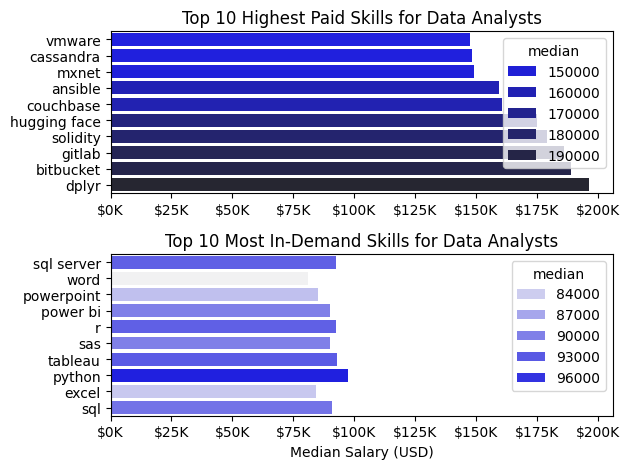

In [10]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US['job_skills']
df_DA_US_group=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay=df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_top_pay
df_DA_skills=df_DA_US_group.sort_values(by='count',ascending=False).head(10)
df_DA_skills


fig,ax=plt.subplots(2,1) 
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r' ,order=df_DA_top_pay.index)
# df_DA_top_pay.plot(kind='barh',y='median',ax=ax[0],legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
sns.barplot(data=df_DA_skills,x='median',y=df_DA_skills.index,ax=ax[1],hue='median',palette='light:b', order=df_DA_skills.index)
# df_DA_skills.plot(kind='barh',y='median',ax=ax[1],legend=False)
ax[1].invert_yaxis()

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Adjust layout to prevent overlapping
fig.tight_layout()
plt.show()